# F1 Strategy Predictor
## Real-Time Pit Stop & Compound Prediction

---

### Obiettivo
**"Predict competitor pit stops in real-time to gain strategic advantage"**

### Il Modello
- **Unidirectional LSTM**: Non usa dati futuri (real-time compatible)
- **Temporal Split**: Train su gare passate, test su gare future
- **Gradient Clipping**: Stabilità del training

### Prerequisiti
- `f1_dataset_clean.pkl` (generato dal notebook DataAnalysis)

# 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
import joblib
import json
import os

os.makedirs('Model', exist_ok=True)
os.makedirs('Other', exist_ok=True)

In [3]:
# FastF1: libreria open-source per dati F1 (telemetria, tempi, meteo)
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.4 MB/s eta 0:00:00


In [4]:
from sklearn.preprocessing import RobustScaler, LabelEncoder

from sklearn.metrics import (confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score,
                             precision_recall_curve)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     Masking, MultiHeadAttention,
                                     LayerNormalization, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibile: {tf.config.list_physical_devices('GPU')}")

# Riproducibilità
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU disponibile: []


# 2. Import Dataset

In [6]:
df_f1 = pd.read_pickle('f1_dataset_clean.pkl')
print(f"Dataset caricato: {len(df_f1):,} righe")

Dataset caricato: 86,757 righe


# 3. Features

In [7]:
FEATURES_PIT = [
    'StintProgress', 'GapToLeader', 'UnderCaution', 'Rainfall',
    'WindSpeed', 'Pressure', 'Humidity', 'TrackTemp', 'AirTemp',
    'Round', 'Position', 'TyreLife', 'SpeedST',
    'SpeedFL', 'SpeedI1', 'SpeedI2', 'Stint', 'LapNumber',
    'Sector1TimeSec', 'Sector2TimeSec', 'Sector3TimeSec',
    'OvercutPotential', 'UndercutPotential',
    'IsSoft', 'IsMedium', 'IsHard', 'IsInter',
    'IsPersonalBest', 'DriverEnc', 'TeamEnc', 'LapTimeSec',
    'GapTrend', 'LapTimeTrend3'
]

In [8]:
FEATURES_COMPOUND = [
    'StintProgress', 'GapToLeader', 'UnderCaution', 'Rainfall',
    'WindSpeed', 'Pressure', 'Humidity', 'TrackTemp', 'AirTemp',
    'Round', 'Position', 'FreshTyre', 'TyreLife', 'SpeedST',
    'SpeedFL', 'SpeedI1', 'SpeedI2', 'Stint', 'LapNumber',
    'Sector1TimeSec', 'Sector2TimeSec', 'Sector3TimeSec',
    'OvercutPotential', 'UndercutPotential',
    'IsSoft', 'IsMedium', 'IsHard', 'IsInter',
    'IsPersonalBest', 'DriverEnc', 'TeamEnc', 'LapTimeSec',
    'GapTrend', 'LapTimeTrend3', 'RaceProgress', 'TyreDegradation'
]

---
# 4. Preparazione Dati per Training

In [9]:
# Filtraggio per training
df_clean = df_f1.dropna(subset=['PitIn3Laps', 'NextCompound'])  # Target validi

In [10]:
# Encoding target compound
label_encoder = LabelEncoder()
df_f1['NextCompoundEnc'] = label_encoder.fit_transform(df_f1['NextCompound'])
print(f"\nClassi: {list(label_encoder.classes_)}")


Classi: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']


### 4.1 Creazione Sequenze Temporali

*Perché sequenze di 10 giri?*
L'LSTM ha bisogno di contesto temporale per catturare i trend: 10 giri è un buon compromesso: abbastanza per vedere il degrado, non troppo per includere rumore. Stint più corti vengono paddati con valMedio (il Masking layer li ignorerà)

In [11]:
SEQUENCE_LENGTH = 10  # Giri di storia per la predizione

# Crea sequenze temporali per LSTM
def create_sequences(df, features, target_col, seq_len):
    """
    Crea sequenze temporali per LSTM.
    Input: (samples, timesteps, features) = (N, 10, 14)
    Per ogni giro, prende i 'seq_len' giri precedenti come input.
    """
    X = []  # Input = sequenza di giri
    y = []  # Output = target (PitIn3Laps o NextCompoundEnc)
    available = [f for f in features if f in df.columns] # Filtra features esistenti

    for (year, rnd, driver, stint), group in df.groupby(['Year', 'Round', 'Driver', 'Stint']):
        group = group.sort_values('LapNumber')
        if len(group) < 3:  # Skip stint troppo corti
            continue

        data = group[available].values.astype(np.float32)
        targets = group[target_col].values

        # Per ogni giro, prendi i 'seq_len' giri precedenti come input per creare la sequenza
        for i in range(1, len(group)):  # Inizia da 1 (serve almeno 1 giro di storia)
            start = max(0, i - seq_len)
            seq = data[start:i]

            # Padding se sequenza troppo corta (padding con zeri)
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), len(available)), dtype=np.float32)
                seq = np.vstack([pad, seq])

            X.append(seq)
            y.append(targets[i])

    return np.array(X), np.array(y), available

In [12]:
# Filtra features esistenti
FEATURES_PIT = [f for f in FEATURES_PIT if f in df_clean.columns]
FEATURES_COMPOUND = [f for f in FEATURES_COMPOUND if f in df_clean.columns]
print(f"Features PIT effettive: {len(FEATURES_PIT)}")
print(f"Features COMPOUND effettive: {len(FEATURES_COMPOUND)}")

# NOTA: Le sequenze verranno create DOPO lo split temporale
# per evitare data leakage tra train/val/test

Features PIT effettive: 33
Features COMPOUND effettive: 36


### 4.2 Split Train/Validation/Test

WHY TEMPORAL? For real-time prediction during a race:
   - You can only train on PAST races
   - You predict on CURRENT/FUTURE races
   - Random split would be cheating (seeing future patterns)

In [13]:
# Sort by time
df_clean = df_clean.sort_values(['Year', 'Round', 'LapNumber']).reset_index(drop=True)

# Create RaceID
df_clean['RaceID'] = df_clean['Year'].astype(str) + '_' + df_clean['Round'].astype(str).str.zfill(2)
unique_races = sorted(df_clean['RaceID'].unique())
n_races = len(unique_races)

# Temporal split: 70% train, 15% val, 15% test (chronologically)
train_cutoff = int(0.70 * n_races)
val_cutoff = int(0.85 * n_races)

train_races = set(unique_races[:train_cutoff])
val_races = set(unique_races[train_cutoff:val_cutoff])
test_races = set(unique_races[val_cutoff:])

print("="*60)
print("TEMPORAL SPLIT FOR REAL-TIME PREDICTION")
print("="*60)
print(f"\nTotal races: {n_races}")
print(f"\nSplit:")
print(f"  Train: {len(train_races)} races ({unique_races[0]} → {unique_races[train_cutoff-1]})")
print(f"  Val:   {len(val_races)} races ({unique_races[train_cutoff]} → {unique_races[val_cutoff-1]})")
print(f"  Test:  {len(test_races)} races ({unique_races[val_cutoff]} → {unique_races[-1]})")

# Split dataframes
df_train = df_clean[df_clean['RaceID'].isin(train_races)].copy()
df_val = df_clean[df_clean['RaceID'].isin(val_races)].copy()
df_test = df_clean[df_clean['RaceID'].isin(test_races)].copy()

print(f"\nLaps per split:")
print(f"  Train: {len(df_train):,} laps")
print(f"  Val:   {len(df_val):,} laps")
print(f"  Test:  {len(df_test):,} laps")

# Create sequences for each split
print("\nCreazione sequenze PIT...")
X_pit_train, y_pit_train, feat_pit = create_sequences(df_train, FEATURES_PIT, 'PitIn3Laps', SEQUENCE_LENGTH)
X_pit_val, y_pit_val, _ = create_sequences(df_val, FEATURES_PIT, 'PitIn3Laps', SEQUENCE_LENGTH)
X_pit_test, y_pit_test, _ = create_sequences(df_test, FEATURES_PIT, 'PitIn3Laps', SEQUENCE_LENGTH)

print(f"  Train: {X_pit_train.shape} | Positive: {y_pit_train.mean():.1%}")
print(f"  Val:   {X_pit_val.shape} | Positive: {y_pit_val.mean():.1%}")
print(f"  Test:  {X_pit_test.shape} | Positive: {y_pit_test.mean():.1%}")

print("\nCreazione sequenze COMPOUND...")
X_comp_train, y_comp_train, feat_comp = create_sequences(df_train, FEATURES_COMPOUND, 'NextCompoundEnc', SEQUENCE_LENGTH)
X_comp_val, y_comp_val, _ = create_sequences(df_val, FEATURES_COMPOUND, 'NextCompoundEnc', SEQUENCE_LENGTH)
X_comp_test, y_comp_test, _ = create_sequences(df_test, FEATURES_COMPOUND, 'NextCompoundEnc', SEQUENCE_LENGTH)

print(f"  Train: {X_comp_train.shape}")
print(f"  Val:   {X_comp_val.shape}")
print(f"  Test:  {X_comp_test.shape}")


TEMPORAL SPLIT FOR REAL-TIME PREDICTION

Total races: 92

Split:
  Train: 64 races (2022_01 → 2024_20)
  Val:   14 races (2024_21 → 2025_10)
  Test:  14 races (2025_11 → 2025_24)

Laps per split:
  Train: 60,742 laps
  Val:   12,622 laps
  Test:  13,393 laps

Creazione sequenze PIT...
  Train: (57417, 10, 33) | Positive: 22.0%
  Val:   (11935, 10, 33) | Positive: 21.3%
  Test:  (12747, 10, 33) | Positive: 19.5%

Creazione sequenze COMPOUND...
  Train: (57417, 10, 36)
  Val:   (11935, 10, 36)
  Test:  (12747, 10, 36)


### 4.3 Normalizzazione e Class Weights

**Normalizzazione**: RobustScaler usa mediana invece di media
- *Perché?* Più robusto agli outliers (pit lap, safety car, outlap)

**Class Weights**: Bilancia le classi sbilanciate
- *Perché?* ~80% dei giri NON sono seguiti da pit -> il modello tenderebbe a predire sempre "no pit"

In [14]:
# Normalizzazione PIT
scaler_pit = RobustScaler()
n_features_pit = X_pit_train.shape[2] #   Shape: (81979, 10, 16)

X_pit_train = scaler_pit.fit_transform(X_pit_train.reshape(-1, n_features_pit)).reshape(X_pit_train.shape)
# = Shape: (81979, 10, 16) -> (819790, 16) -> norm -> (81979, 10, 16)
X_pit_val = scaler_pit.transform(X_pit_val.reshape(-1, n_features_pit)).reshape(X_pit_val.shape)
X_pit_test = scaler_pit.transform(X_pit_test.reshape(-1, n_features_pit)).reshape(X_pit_test.shape)


# Normalizzazione COMPOUND
scaler_comp = RobustScaler()
n_features_comp = X_comp_train.shape[2]   # Shape: (81979, 10, 15)

X_comp_train = scaler_comp.fit_transform(X_comp_train.reshape(-1, n_features_comp)).reshape(X_comp_train.shape)
# = Shape: (81979, 10, 15) -> (819790, 15) -> norm -> (81979, 10, 15)
X_comp_val = scaler_comp.transform(X_comp_val.reshape(-1, n_features_comp)).reshape(X_comp_val.shape)
X_comp_test = scaler_comp.transform(X_comp_test.reshape(-1, n_features_comp)).reshape(X_comp_test.shape)

In [15]:
pit_counts = np.bincount(y_pit_train.astype(int))
pit_weight = {0: 1.0, 1: min(pit_counts[0]/pit_counts[1], 10.0)}


comp_counts = np.bincount(y_comp_train)
n_classes = len(comp_counts)

comp_weight = {}
for i, cls in enumerate(label_encoder.classes_):
    base_w = len(y_comp_train) / (n_classes * comp_counts[i])
    if cls == 'HARD':
        comp_weight[i] = min(base_w * 0.7, 1.0)  # Reduce
    elif cls == 'INTERMEDIATE':
        comp_weight[i] = base_w
    elif cls in ['MEDIUM', 'SOFT']:
        comp_weight[i] = base_w * 1.5  # Boost
    else:
        comp_weight[i] = base_w

print(f'PIT weight: {pit_weight}')
print(f'COMPOUND weights: {comp_weight}')

PIT weight: {0: 1.0, 1: np.float64(3.536741466498104)}
COMPOUND weights: {0: np.float64(0.3277439819949116), 1: np.float64(5.229234972677595), 2: np.float64(1.3819881258023108), 3: np.float64(2.552925658050747)}


---
# 5. Modelli LSTM

### 5.1 Architettura Modello PIT

**Scelte architetturali:**

1. **Unidirectional LSTM**: Cattura pattern temporali in 1 sola direzione

2. **Multi-Head Self-Attention**: Permette al modello di "pesare" quali giri sono più importanti
   - *Perché?* In un contesto di gara, la strategia dipende da pattern distribuiti (stint length, finestre di pit, traffico), non da una singola dinamica locale. L’attenzione permette di confrontare direttamente giri distanti tra loro.

3. **Residual Connection**: Migliora il gradient flow
   - *Perché?* Permette ai gradienti di fluire direttamente, evitando vanishing gradient

4. **Masking**: Ignora i padding (zeri) nelle sequenze corte

In [ ]:
def build_pit_model(seq_len, n_features):
    """
    PIT STOP PREDICTION MODEL - Final Production Version

    Architecture: Unidirectional LSTM + Attention
    - Unidirectional: Required for real-time (no future data)
    - Optimized regularization based on training analysis

    Input: (batch, seq_len, n_features)
    Output: (batch, 1) - probability of pit in next 3 laps
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    # Masking for padded sequences
    x = Masking(mask_value=0.0)(inputs)
    x = GaussianNoise(0.05)(x)

    # LSTM Layer 1 - Unidirectional (real-time compatible)
    x = LSTM(128, return_sequences=True,
             dropout=0.4,              # Increased from 0.2
             recurrent_dropout=0.2)(x)  # Increased from 0.1
    x = LayerNormalization()(x)

    # Multi-Head Self-Attention
    attention = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.1
    )(x, x)
    x = Add()([x, attention])  # Residual connection
    x = LayerNormalization()(x)

    # LSTM Layer 2
    x = LSTM(64, dropout=0.4, recurrent_dropout=0.2)(x)

    # Dense layers with regularization
    x = Dense(48, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)  # Increased from 0.3

    x = Dense(24, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = Dropout(0.3)(x)  # Increased from 0.2

    # Output
    output = Dense(1, activation='sigmoid', name='pit')(x)

    model = Model(inputs=inputs, outputs=output)

    # Optimizer with gradient clipping for stability
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0  # Gradient clipping
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='prec'),
            tf.keras.metrics.Recall(name='rec')
        ]
    )

    return model

model_pit = build_pit_model(SEQUENCE_LENGTH, len(feat_pit))
model_pit.summary()

Building PIT model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 35)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 10, 35)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10, 35)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 10, 35)    │          0 │ masking[0][0]     │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 10)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 10, 128)   │     83,968 │ gaussian_noise[0… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 128)   │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 10)        │          0 │ any[0][0],        │
│ (LogicalOr)         │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ layer_normalizat… │
│                     │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │      3,120 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48)        │        192 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24)        │      1,176 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pit (Dense)         │ (None, 1)         │         25 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 204,449 (798.63 KB)

 Trainable params: 204,353 (798.25 KB)

 Non-trainable params: 96 (384.00 B)


Features used: 35
Features: ['StintProgress', 'GapToLeader', 'UnderCaution', 'Rainfall', 'WindSpeed', 'Pressure', 'Humidity', 'TrackTemp', 'AirTemp', 'Round', 'Position', 'FreshTyre', 'TyreLife', 'SpeedST', 'SpeedFL', 'SpeedI1', 'SpeedI2', 'Stint', 'LapNumber', 'Sector1TimeSec', 'Sector2TimeSec', 'Sector3TimeSec', 'IsStreetCircuit', 'IsPowerCircuit', 'IsTechnicalCircuit', 'IsSoft', 'IsMedium', 'IsHard', 'IsInter', 'IsPersonalBest', 'Driver', 'Team', 'LapTimeSec', 'GapTrend', 'LapTimeTrend3']


### 5.2 Training Modello PIT

In [ ]:
# Callbacks:
# - EarlyStopping: ferma se val_auc non migliora per 12 epoche
# - ReduceLROnPlateau: riduce learning rate se val_loss non migliora
callbacks_pit = [
    EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training PIT model...")
print("="*60)
history_pit = model_pit.fit(
    X_pit_train, y_pit_train,
    validation_data=(X_pit_val, y_pit_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks_pit,
    class_weight=pit_weight,
    verbose=1
)

Training PIT model...
Epoch 1/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.5419 - auc: 0.6082 - loss: 1.3626 - prec: 0.3674 - rec: 0.6792 - val_accuracy: 0.6558 - val_auc: 0.7188 - val_loss: 0.7673 - val_prec: 0.4681 - val_rec: 0.6757 - learning_rate: 0.0010
Epoch 2/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - accuracy: 0.6387 - auc: 0.7001 - loss: 0.9939 - prec: 0.4384 - rec: 0.6804 - val_accuracy: 0.6440 - val_auc: 0.7121 - val_loss: 0.6860 - val_prec: 0.4569 - val_rec: 0.6873 - learning_rate: 0.0010
Epoch 3/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.6743 - auc: 0.7440 - loss: 0.8680 - prec: 0.4749 - rec: 0.6972 - val_accuracy: 0.5931 - val_auc: 0.7204 - val_loss: 0.6693 - val_prec: 0.4213 - val_rec: 0.7788 - learning_rate: 0.0010
Epoch 4/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - accuracy: 0.6944 - auc: 0.7708 - loss: 0.8104 - prec: 0.4976 - rec: 0.7129 - val_accuracy: 0.6356 - val_auc: 0.7305 - val_loss: 0.6675 - val_prec: 0.4523 - val_rec:

### 5.3 Architettura Modello COMPOUND

**Architettura simile al PIT con output multiclass:**

1. **Stessa struttura LSTM + Attention** - cattura pattern temporali
2. **Output softmax** - per 5 classi mutualmente esclusive
3. **160 neurons** - necessari più neuroni per apprendere pattern più complessi

In [ ]:
def build_compound_model(seq_len, n_features, n_classes):
    """
    COMPOUND PREDICTION MODEL - Final Production Version

    Architecture: Unidirectional LSTM + Attention
    - Lower learning rate to reduce training spikes
    - Optimized regularization

    Input: (batch, seq_len, n_features)
    Output: (batch, n_classes) - probability for each compound
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    x = Masking(mask_value=0.0)(inputs)
    x = GaussianNoise(0.05)(x)

    # LSTM + Attention (same structure as PIT)
    x = LSTM(160, return_sequences=True, dropout=0.4, recurrent_dropout=0.2)(x)

    x = LayerNormalization()(x)

    attention = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.15
    )(x, x)
    x = Add()([x, attention])
    x = LayerNormalization()(x)

    x = LSTM(80, dropout=0.4, recurrent_dropout=0.2)(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = Dropout(0.3)(x)

    # Output: softmax for multiclass
    output = Dense(n_classes, activation='softmax', name='compound')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0008, clipnorm=1.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    return model


n_classes = len(label_encoder.classes_)
model_comp = build_compound_model(SEQUENCE_LENGTH, len(feat_comp), n_classes)
model_comp.summary()

Building COMPOUND model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 37)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 10, 37)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 10, 37)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 10, 37)    │          0 │ masking_1[0][0]   │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 10)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 160)   │    126,720 │ gaussian_noise_1… │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 160)   │        320 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 160)   │     82,464 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 160)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 160)   │        320 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 10)        │          0 │ any_1[0][0],      │
│ (LogicalOr)         │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 80)        │     77,120 │ layer_normalizat… │
│                     │                   │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      5,184 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ compound (Dense)    │ (None, 4)         │        132 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 294,596 (1.12 MB)

 Trainable params: 294,468 (1.12 MB)

 Non-trainable params: 128 (512.00 B)


Classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']
Features used: 37


### 5.4 Training Modello COMPOUND

In [ ]:
callbacks_comp = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

print("\nTraining COMPOUND model...")
print("="*60)
history_comp = model_comp.fit(
    X_comp_train, y_comp_train,
    validation_data=(X_comp_val, y_comp_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks_comp,
    class_weight=comp_weight,
    verbose=1
)


Training COMPOUND model...
Epoch 1/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.2799 - loss: 2.2655 - val_accuracy: 0.4142 - val_loss: 1.4385 - learning_rate: 8.0000e-04
Epoch 2/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - accuracy: 0.3474 - loss: 1.4804 - val_accuracy: 0.3978 - val_loss: 1.3980 - learning_rate: 8.0000e-04
Epoch 3/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.4031 - loss: 1.1863 - val_accuracy: 0.4755 - val_loss: 1.2580 - learning_rate: 8.0000e-04
Epoch 4/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.4598 - loss: 1.0120 - val_accuracy: 0.5507 - val_loss: 1.1862 - learning_rate: 8.0000e-04
Epoch 5/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - accuracy: 0.5372 - loss: 0.9091 - val_accuracy: 0.6263 - val_loss: 1.0976 - learning_rate: 8.0000e-04
Epoch 6/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - accuracy: 0.6016 - loss: 0.8307 - val_accuracy: 0.5889 - val_loss: 1.2308 - learning_rate: 8.0000e-04
Epoch 7/50
454/454 ━━━━

---
# 6. Valutazione

### 6.1 Metriche

**Metriche PIT:**
- **AUC-ROC**: Metrica principale, misura la capacità di distinguere tra Pit e No Pit indipendentemente dalla soglia
- **F1 Score**: Bilancia Precision e Recall
- **Soglia ottimale**: Trovata massimizzando F1 sulla curva precision-recall

In [ ]:
# ------ MODELLO PIT ------
print("\n" + "-"*50)
print("MODELLO PIT (PitIn3Laps)")
print("-"*50)

# Predizioni
y_pit_pred_prob = model_pit.predict(X_pit_test, verbose=0).flatten()

# Trova soglia ottimale (massimizza F1)
prec, rec, thresh = precision_recall_curve(y_pit_test, y_pit_pred_prob)
f1_arr = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1_arr)
opt_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

y_pit_pred = (y_pit_pred_prob > opt_thresh).astype(int)

# Metriche
pit_auc = roc_auc_score(y_pit_test, y_pit_pred_prob)
pit_f1 = f1_score(y_pit_test, y_pit_pred)
pit_acc = accuracy_score(y_pit_test, y_pit_pred)

print(f"AUC-ROC:   {pit_auc:.3f}")
print(f"F1 Score:  {pit_f1:.3f}")
print(f"Accuracy:  {pit_acc:.3f}")
print(f"Precision: {prec[best_idx]:.3f}")
print(f"Recall:    {rec[best_idx]:.3f}")
print(f"Soglia:    {opt_thresh:.3f}")

cm_pit = confusion_matrix(y_pit_test, y_pit_pred)
print(f"\nConfusion Matrix:")
print(f"           Pred:0  Pred:1")
print(f"True:0     {cm_pit[0,0]:6d}  {cm_pit[0,1]:6d}")
print(f"True:1     {cm_pit[1,0]:6d}  {cm_pit[1,1]:6d}")


--------------------------------------------------
MODELLO PIT (PitIn3Laps)
--------------------------------------------------
AUC-ROC:   0.792
F1 Score:  0.565
Accuracy:  0.721
Precision: 0.462
Recall:    0.728
Soglia:    0.528

Confusion Matrix:
           Pred:0  Pred:1
True:0       6918    2714
True:1        870    2330


**Metriche COMPOUND:**
- **Accuracy**: Proporzione di predizioni corrette
- **F1 (weighted)**: Media pesata degli F1 per classe
- **Per-class accuracy**: Per identificare classi problematiche

In [ ]:
# ------ MODELLO COMPOUND ------
print("\n" + "-"*50)
print("MODELLO COMPOUND (NextCompound)")
print("-"*50)

y_comp_pred_prob = model_comp.predict(X_comp_test, verbose=0)
y_comp_pred = y_comp_pred_prob.argmax(axis=1)

comp_acc = accuracy_score(y_comp_test, y_comp_pred)
comp_f1 = f1_score(y_comp_test, y_comp_pred, average='weighted')

print(f"Accuracy:  {comp_acc:.3f}")
print(f"F1 (weighted): {comp_f1:.3f}")

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(label_encoder.classes_):
    mask = y_comp_test == i
    if mask.sum() > 0:
        cls_acc = (y_comp_pred[mask] == i).mean()
        cls_pred_count = (y_comp_pred == i).sum()
        print(f"  {cls:12s}: {cls_acc:.3f} (n={mask.sum():,}, pred={cls_pred_count:,})")

print(f"\nConfusion Matrix:")
cm_comp = confusion_matrix(y_comp_test, y_comp_pred)
print(f"Classes: {list(label_encoder.classes_)}")
print(cm_comp)


--------------------------------------------------
MODELLO COMPOUND (NextCompound)
--------------------------------------------------
Accuracy:  0.643
F1 (weighted): 0.648

Per-class accuracy:
  HARD        : 0.679 (n=5,458, pred=4,746)
  INTERMEDIATE: 0.333 (n=60, pred=133)
  MEDIUM      : 0.674 (n=4,755, pred=5,111)
  SOFT        : 0.517 (n=2,559, pred=2,842)

Confusion Matrix:
Classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']
[[3704   19 1258  477]
 [   0   20   13   27]
 [ 445   89 3205 1016]
 [ 597    5  635 1322]]


### 6.2 Training History

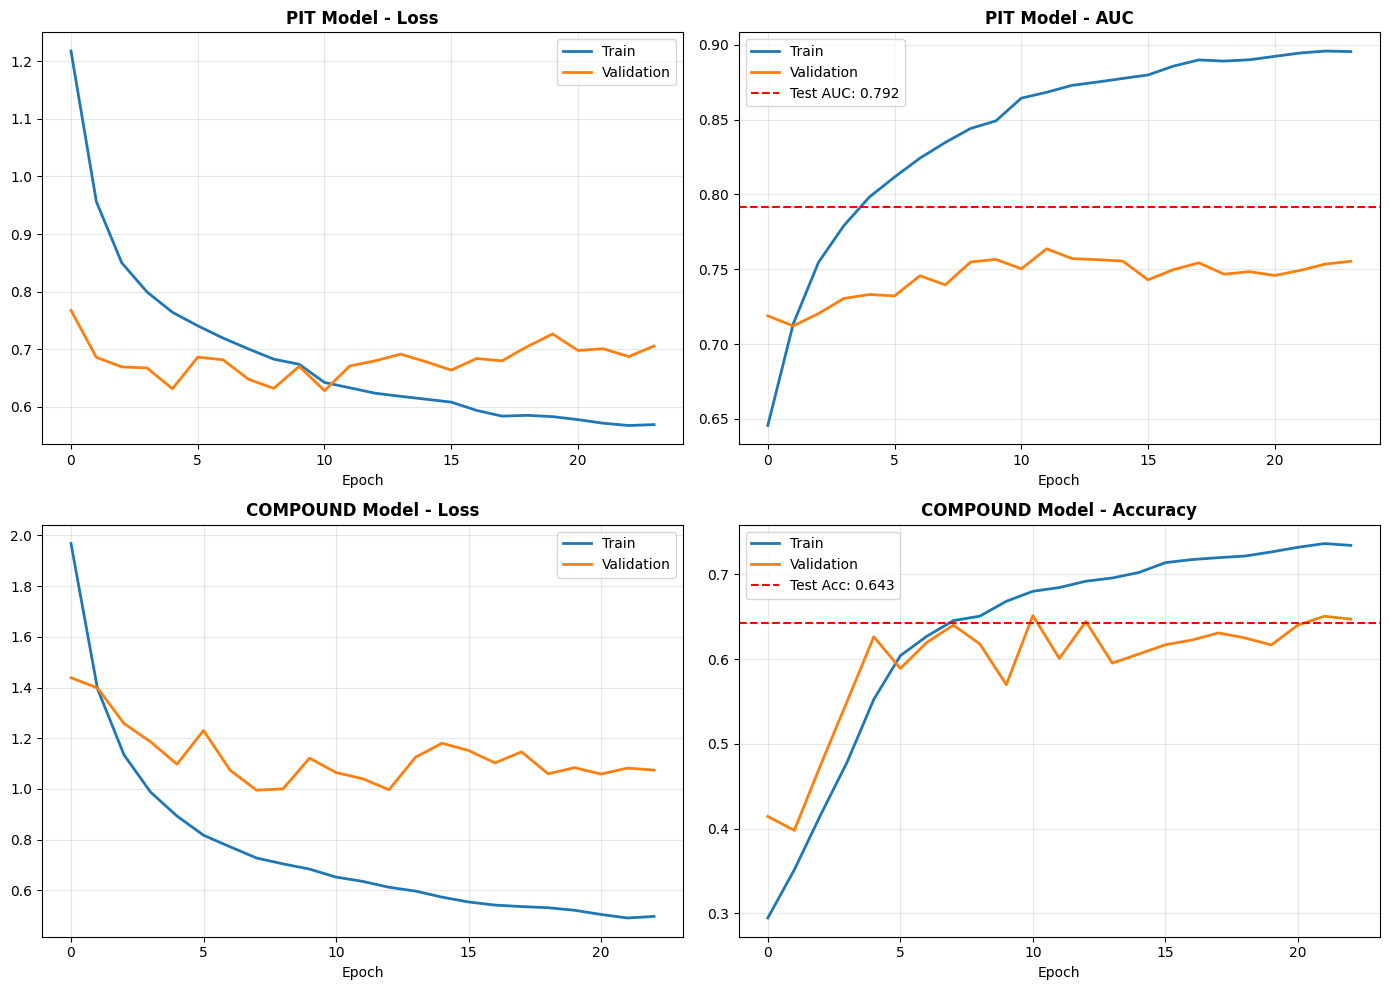

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PIT - Loss
axes[0, 0].plot(history_pit.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history_pit.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('PIT Model - Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# PIT - AUC
axes[0, 1].plot(history_pit.history['auc'], label='Train', linewidth=2)
axes[0, 1].plot(history_pit.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].axhline(y=pit_auc, color='r', linestyle='--', label=f'Test AUC: {pit_auc:.3f}')
axes[0, 1].set_title('PIT Model - AUC', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# COMPOUND - Loss
axes[1, 0].plot(history_comp.history['loss'], label='Train', linewidth=2)
axes[1, 0].plot(history_comp.history['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('COMPOUND Model - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# COMPOUND - Accuracy
axes[1, 1].plot(history_comp.history['accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(history_comp.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axhline(y=comp_acc, color='r', linestyle='--', label=f'Test Acc: {comp_acc:.3f}')
axes[1, 1].set_title('COMPOUND Model - Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Other/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 7. Save

In [ ]:
# Salva modelli Keras
model_pit.save('Model/f1_pit_model.keras')
model_comp.save('Model/f1_compound_model.keras')

✓ Modelli salvati


In [ ]:
# Salva scaler e encoder
joblib.dump(scaler_pit, 'Model/f1_pit_scaler.pkl')
joblib.dump(scaler_comp, 'Model/f1_comp_scaler.pkl')
joblib.dump(label_encoder, 'Model/label_encoder.pkl')

✓ Scaler e encoder salvati


In [ ]:
# Salva configurazione
config = {
    'sequence_length': SEQUENCE_LENGTH,
    'features_pit': feat_pit,
    'features_compound': feat_comp,
    'pit_threshold': float(opt_thresh),
    'compound_classes': list(label_encoder.classes_),
    'metrics': {
        'pit_auc': float(pit_auc),
        'pit_f1': float(pit_f1),
        'pit_accuracy': float(pit_acc),
        'compound_accuracy': float(comp_acc),
        'compound_f1': float(comp_f1)
    }
}

with open('Model/modelConfig.json', 'w') as f:
    json.dump(config, f, indent=2)

✓ Configurazione salvata


In [ ]:
# Salva il dataset completo con tutte le features
df_f1.to_pickle('Other/f1_dataset_featured.pkl')

print("✓ Dataset con features salvato")

✓ Dataset con features salvato

TRAINING COMPLETATO!

PIT Model:      AUC=0.792, F1=0.565
COMPOUND Model: Accuracy=0.643, F1=0.648
